## 📊 Key Statistical Findings

1. Campaign 1 acceptors spend 2.7x more (p=0.0000) ✅
2. Education level significantly affects purchases (p=0.0000) ✅  
3. Marital status has no influence on campaign acceptance (p=0.923) ❌
4. Campaign 3 and Campaign 5 perform equally — no winner (p=0.954) 🤝

Business Recommendation:
Target high-income, educated customers.
Use Campaign 4 as primary campaign.
Choose Campaign 3 or 5 based on cost — performance is identical.

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load your cleaned data from Phase 3
df = pd.read_csv('cleaned_data.csv')
print("Shape:", df.shape)
print("Loaded successfully!")

Shape: (2236, 33)
Loaded successfully!


In [3]:
# Basic statistics for all numeric columns
desc = df[['Income', 'Age', 'Total_Spend',
           'Total_Campaigns_Accepted']].describe()
print(desc)

              Income          Age  Total_Spend  Total_Campaigns_Accepted
count    2236.000000  2236.000000  2236.000000               2236.000000
mean    51952.614043    57.101968   605.986583                  0.297853
std     21411.466851    11.703281   601.865156                  0.678737
min      1730.000000    30.000000     5.000000                  0.000000
25%     35502.500000    49.000000    69.000000                  0.000000
50%     51381.500000    56.000000   396.500000                  0.000000
75%     68275.750000    67.000000  1045.500000                  0.000000
max    162397.000000    86.000000  2525.000000                  4.000000


What is a T-Test?

A T-test is a statistical test used to compare the average (mean) values of two groups and determine whether the difference between them is statistically significant.

After performing the test, we mainly obtain:

T-statistic (T-value) → measures how large the difference is between the two groups.
P-value → measures the probability that the observed difference happened by random chance.

In general:

A larger absolute t-value indicates a stronger difference between the groups.
If the p-value is less than 0.05, the result is considered statistically significant.

This means we can reject the null hypothesis and conclude that the difference between the two groups is unlikely to have occurred by random chance.

In [4]:
# Split into two groups
accepted = df[df['AcceptedCmp1'] == 1]['Total_Spend']
not_accepted = df[df['AcceptedCmp1'] == 0]['Total_Spend']

# Run t-test
t_stat, p_value = stats.ttest_ind(accepted, not_accepted)

print("=== Hypothesis Test 1 ===")
print("H0: Campaign 1 acceptors spend the SAME as non-acceptors")
print("H1: Campaign 1 acceptors spend MORE")
print(f"\nGroup 1 (Accepted) avg spend: £{accepted.mean():.2f}")
print(f"Group 2 (Not Accepted) avg spend: £{not_accepted.mean():.2f}")
print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ RESULT: Reject H0 — The difference is REAL")
else:
    print("\n❌ RESULT: Fail to reject H0 — Difference could be chance")

=== Hypothesis Test 1 ===
H0: Campaign 1 acceptors spend the SAME as non-acceptors
H1: Campaign 1 acceptors spend MORE

Group 1 (Accepted) avg spend: £1482.22
Group 2 (Not Accepted) avg spend: £545.67

t-statistic: 19.5399
p-value: 0.0000

✅ RESULT: Reject H0 — The difference is REAL


What is ANOVA?

ANOVA (Analysis of Variance) is a statistical test used to compare the average (mean) values of more than two groups and determine whether there is a statistically significant difference between them.

After performing the test, we mainly obtain:

F-statistic (F-value) → measures the variation between the groups.
P-value → measures the probability that the observed difference happened by random chance.

In general:

A larger F-value indicates a stronger difference between the groups.
If the p-value is less than 0.05, the result is considered statistically significant.

This means we can reject the null hypothesis and conclude that at least one group mean is different from the others.

In [5]:
# Separate total purchases by education group
df['Total_Purchases'] = (df['NumWebPurchases'] +
                          df['NumStorePurchases'] +
                          df['NumCatalogPurchases'])

# Create separate group for each education level
basic = df[df['Education'] == 'Basic']['Total_Purchases']
graduation = df[df['Education'] == 'Graduation']['Total_Purchases']
master = df[df['Education'] == 'Master']['Total_Purchases']
phd = df[df['Education'] == 'PhD']['Total_Purchases']
cycle = df[df['Education'] == '2n Cycle']['Total_Purchases']

# Run ANOVA
f_stat, p_value = stats.f_oneway(basic, graduation, master, phd, cycle)

print("=== Hypothesis Test 2 — ANOVA ===")
print("H0: Education level has NO effect on purchases")
print("H1: At least one education group purchases differently")
print(f"\nF-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ RESULT: Reject H0 — Education DOES affect purchases")
else:
    print("\n❌ RESULT: Fail to reject H0 — No proven difference")

=== Hypothesis Test 2 — ANOVA ===
H0: Education level has NO effect on purchases
H1: At least one education group purchases differently

F-statistic: 17.2727
p-value: 0.0000

✅ RESULT: Reject H0 — Education DOES affect purchases


/tmp/ipykernel_2083/3349599441.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Education', y='Total_Purchases',


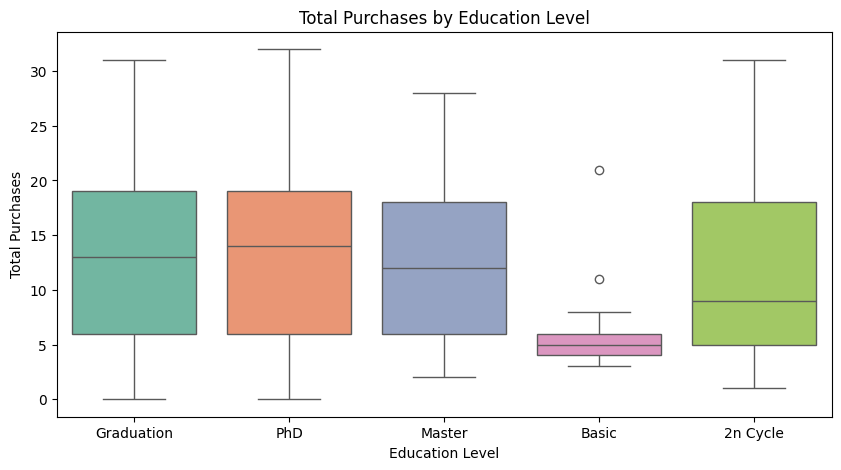

In [6]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Education', y='Total_Purchases',
            data=df, palette='Set2')
plt.title('Total Purchases by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Total Purchases')
plt.show()

In [7]:
avg_by_education = df.groupby('Education')['Total_Purchases'].agg(['mean', 'count'])
avg_by_education.columns = ['Avg Purchases', 'Customer Count']
avg_by_education = avg_by_education.round(2)
print(avg_by_education.sort_values('Avg Purchases', ascending=False))

            Avg Purchases  Customer Count
Education                                
PhD                 13.45             485
Graduation          12.69            1126
Master              12.50             370
2n Cycle            11.63             201
Basic                5.22              54


What is a Chi-Square Test?

A Chi-Square test is a statistical test used to determine whether there is a significant association or relationship between two categorical variables.

After performing the test, we mainly obtain:

Chi-square statistic (χ² value) → measures the difference between observed and expected values.
P-value → measures the probability that the observed relationship happened by random chance.

In general:

A larger chi-square value indicates a stronger association between the variables.
If the p-value is less than 0.05, the result is considered statistically significant.

This means we can reject the null hypothesis and conclude that there is a meaningful relationship between the two categorical variables.

In [8]:
from scipy.stats import chi2_contingency

# Create a contingency table
# This counts how many people in each marital status accepted any campaign
df['Any_Campaign'] = (df['Total_Campaigns_Accepted'] > 0).astype(int)

contingency_table = pd.crosstab(df['Marital_Status'], df['Any_Campaign'])
print("=== Contingency Table ===")
print(contingency_table)
print("\nColumns: 0 = Did not accept | 1 = Accepted at least one campaign")

=== Contingency Table ===
Any_Campaign      0    1
Marital_Status          
Divorced        185   46
Married         682  182
Other             5    2
Single          381   98
Together        463  115
Widow            58   19

Columns: 0 = Did not accept | 1 = Accepted at least one campaign


In [9]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\n=== Hypothesis Test 3 — Chi-Square ===")
print("H0: Marital Status and Campaign Acceptance are NOT related")
print("H1: Marital Status DOES influence Campaign Acceptance")
print(f"\nChi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ RESULT: Reject H0 — Marital Status DOES affect campaign acceptance")
else:
    print("\n❌ RESULT: Fail to reject H0 — No proven relationship")


=== Hypothesis Test 3 — Chi-Square ===
H0: Marital Status and Campaign Acceptance are NOT related
H1: Marital Status DOES influence Campaign Acceptance

Chi-square statistic: 1.4070
Degrees of freedom: 5
p-value: 0.9235

❌ RESULT: Fail to reject H0 — No proven relationship


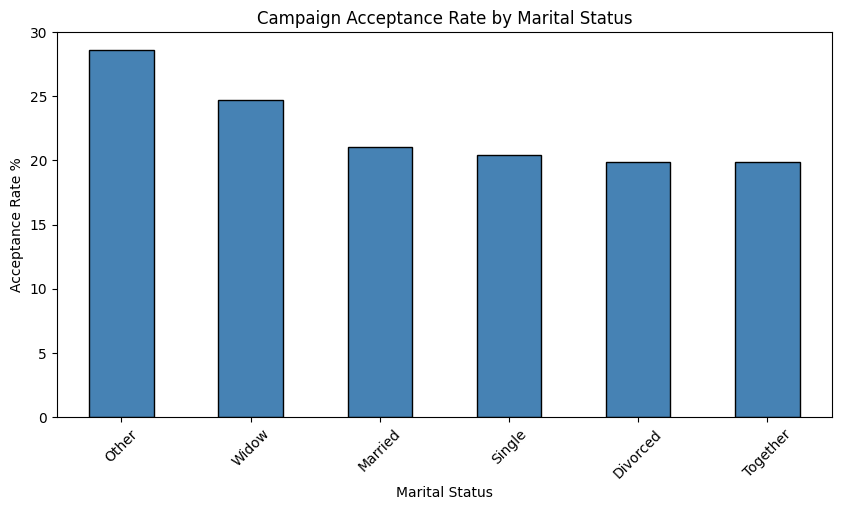

In [10]:
# Calculate acceptance rate per marital status group
acceptance_rate = df.groupby('Marital_Status')['Any_Campaign'].mean() * 100

plt.figure(figsize=(10,5))
acceptance_rate.sort_values(ascending=False).plot(kind='bar',
                                                   color='steelblue',
                                                   edgecolor='black')
plt.title('Campaign Acceptance Rate by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Acceptance Rate %')
plt.xticks(rotation=45)
plt.show()

What is A/B Testing?

A/B Testing is a method used to compare two versions (Version A and Version B) to determine which one performs better.

In A/B testing:

Group A receives the original version.
Group B receives the modified version.

The performance of both groups is compared using metrics such as:

conversion rate,
click rate,
sales,
user engagement, etc.

After performing the test, we mainly analyze:

the difference in performance between the two groups,
and the p-value to check statistical significance.

If the p-value is less than 0.05, the result is considered statistically significant.

This means we can conclude that one version performs better than the other and the result is unlikely to have occurred by random chance.

In [11]:
# Total customers in each group
total = len(df)

# Group A — Campaign 3
campaign3_accepted = df['AcceptedCmp3'].sum()
campaign3_rate = campaign3_accepted / total

# Group B — Campaign 5
campaign5_accepted = df['AcceptedCmp5'].sum()
campaign5_rate = campaign5_accepted / total

print("=== A/B Test Setup ===")
print(f"Total Customers: {total}")
print(f"\nCampaign 3 (A):")
print(f"  Accepted: {campaign3_accepted}")
print(f"  Conversion Rate: {campaign3_rate:.4%}")
print(f"\nCampaign 5 (B):")
print(f"  Accepted: {campaign5_accepted}")
print(f"  Conversion Rate: {campaign5_rate:.4%}")

=== A/B Test Setup ===
Total Customers: 2236

Campaign 3 (A):
  Accepted: 163
  Conversion Rate: 7.2898%

Campaign 5 (B):
  Accepted: 162
  Conversion Rate: 7.2451%


In [12]:
from scipy import stats

# Run t-test between the two campaigns
t_stat, p_value = stats.ttest_ind(
    df['AcceptedCmp3'],
    df['AcceptedCmp5']
)

print("=== A/B Test Results ===")
print("H0: Campaign 3 and Campaign 5 perform the SAME")
print("H1: One campaign performs significantly better")
print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    if campaign3_rate > campaign5_rate:
        print("\n✅ WINNER: Campaign 3 performs significantly better!")
    else:
        print("\n✅ WINNER: Campaign 5 performs significantly better!")
else:
    print("\n🤝 NO WINNER: No significant difference between campaigns")

=== A/B Test Results ===
H0: Campaign 3 and Campaign 5 perform the SAME
H1: One campaign performs significantly better

t-statistic: 0.0576
p-value: 0.9541

🤝 NO WINNER: No significant difference between campaigns


In [13]:
import statsmodels.stats.proportion as prop

# Confidence interval for Campaign 3
ci3_low, ci3_high = prop.proportion_confint(
    campaign3_accepted, total, alpha=0.05)

# Confidence interval for Campaign 5
ci5_low, ci5_high = prop.proportion_confint(
    campaign5_accepted, total, alpha=0.05)

print("=== 95% Confidence Intervals ===")
print(f"Campaign 3: {campaign3_rate:.4%} [{ci3_low:.4%} to {ci3_high:.4%}]")
print(f"Campaign 5: {campaign5_rate:.4%} [{ci5_low:.4%} to {ci5_high:.4%}]")

=== 95% Confidence Intervals ===
Campaign 3: 7.2898% [6.2123% to 8.3673%]
Campaign 5: 7.2451% [6.1706% to 8.3196%]


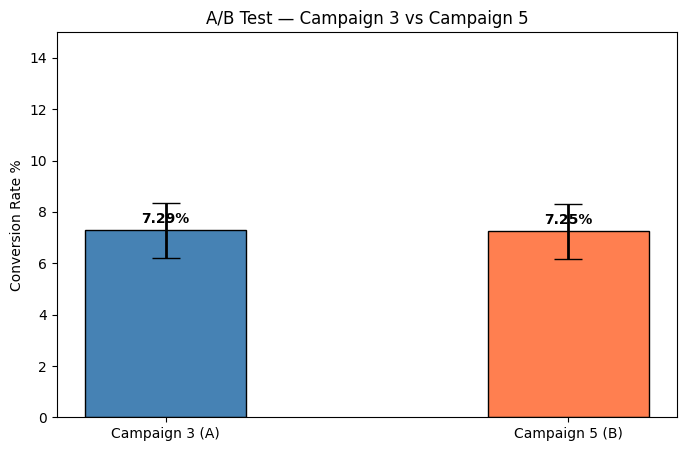

In [14]:
campaigns = ['Campaign 3 (A)', 'Campaign 5 (B)']
rates = [campaign3_rate * 100, campaign5_rate * 100]
errors = [
    (ci3_high - ci3_low) * 100 / 2,
    (ci5_high - ci5_low) * 100 / 2
]

plt.figure(figsize=(8, 5))
bars = plt.bar(campaigns, rates,
               color=['steelblue', 'coral'],
               edgecolor='black',
               width=0.4)

plt.errorbar(campaigns, rates,
             yerr=errors,
             fmt='none',
             color='black',
             capsize=10,
             linewidth=2)

plt.title('A/B Test — Campaign 3 vs Campaign 5')
plt.ylabel('Conversion Rate %')
plt.ylim(0, 15)

for bar, rate in zip(bars, rates):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{rate:.2f}%',
             ha='center', fontweight='bold')

plt.show()